In [24]:
import os
import pandas as pd

PATH = r"D:\Projects\Big\opra\data\evaluation_results\matrix"

runs_wide_df_path = os.path.join(PATH, "runs_wide.csv")
runs_wide_df = pd.read_csv(runs_wide_df_path)

runs_wide_df

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Projects\\Big\\opra\\data\\evaluation_results\\matrix\\runs_wide.csv'

In [ ]:
import os

aggregated_path = os.path.join(PATH, "aggregated.csv")
aggregated_df = pd.read_csv(aggregated_path)

aggregated_df

,log,policy,num_runs,num_cases_mean,num_cases_ci95,avg_ct_mean,avg_ct_ci95,median_ct_mean,median_ct_ci95,std_ct_mean,...,ced_mean,ced_ci95,red_mean,red_ci95,cwd_mean,cwd_ci95,car_mean,car_ci95,ctd_mean,ctd_ci95
0,AcademicCredentials,RA-RR,10,398.0,0.0,8.936916e+05,30744.063302,6.037925e+05,36111.399646,9.451695e+05,...,1.913722,0.126147,30.236051,2.843922,1.965529,0.130307,89.716583,15.572395,66.141960,8.423341
1,AcademicCredentials,DM-RR,10,398.0,0.0,7.723986e+05,15218.502546,4.968563e+05,28387.203130,8.565893e+05,...,2.033990,0.100173,22.792890,1.592646,2.066536,0.106695,89.828894,15.738530,34.245226,4.063012
2,AcademicCredentials,DM-GR,10,398.0,0.0,7.195989e+05,18011.624634,7.797813e+05,21075.140481,4.612265e+05,...,2.251696,0.167154,31.215534,0.542129,2.067188,0.213504,85.627889,14.469960,92.970352,3.196864
3,AcademicCredentials,DM-DRL,10,398.0,0.0,3.461832e+05,19669.201522,1.119150e+05,11458.564390,5.825766e+05,...,2.526975,0.134141,28.876464,2.456804,2.472791,0.105926,89.971106,15.501901,86.256533,5.441342
4,AcademicCredentials,DRL-DRL,10,398.0,0.0,5.954499e+04,5623.011644,5.218550e+03,1221.078087,1.855043e+05,...,2.705649,0.185337,70.395182,0.736401,2.679190,0.197935,88.323618,15.356740,165.789950,1.558683
5,BPIC_2012,RA-RR,10,3030.0,0.0,6.142977e+05,15727.648139,3.443310e+05,5586.718606,9.056094e+05,...,2.130098,0.067119,66.630902,1.832543,1.385876,0.054121,168.873861,23.393039,42.853366,3.005485
6,BPIC_2012,DM-RR,10,3030.0,0.0,1.150360e+06,34429.410263,4.995647e+05,19890.941713,2.058477e+06,...,2.179921,0.072564,118.815052,6.886642,1.436040,0.035689,169.429736,23.182397,170.254752,9.561021
7,BPIC_2012,DM-GR,10,3030.0,0.0,9.482613e+05,13343.963067,6.324337e+05,4518.991844,1.153086e+06,...,3.062355,0.094654,50.567539,2.688338,1.924519,0.058742,172.759868,23.479437,114.134950,3.705884
8,BPIC_2012,DM-DRL,10,3030.0,0.0,1.093249e+06,29906.616308,4.829374e+05,24687.186903,1.864252e+06,...,2.102894,0.043897,103.831202,7.460621,1.371707,0.024056,170.825479,23.019001,154.390462,8.307602
9,BPIC_2012,DRL-DRL,10,3030.0,0.0,8.996555e+03,425.266342,1.198779e+02,3.402636,7.363479e+04,...,2.697091,0.075318,164.989165,0.265003,2.177734,0.129881,176.246799,23.287746,146.505149,0.117786


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_policy_bar_for_log(
    log_name,
    column,
    df=aggregated_df,
    figsize=(9, 5),
    sort_desc=True,
    show_ci=True,
):
    log_df = df[df["log"] == log_name].copy()

    if log_df.empty:
        raise ValueError(f"No rows found for log='{log_name}'.")

    # Accept both "metric" and "metric_mean"
    value_col = column if column in log_df.columns else f"{column}_mean"

    if value_col not in log_df.columns:
        raise ValueError(f"Column '{column}' not found.")

    ci_col = value_col.replace("_mean", "_ci95")

    if sort_desc:
        log_df = log_df.sort_values(value_col, ascending=False)

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=log_df,
        x="policy",
        y=value_col,
        hue="policy",          # fixes FutureWarning
        palette="viridis",
        legend=False,
    )

    if show_ci and ci_col in log_df.columns:
        ax.errorbar(
            range(len(log_df)),
            log_df[value_col],
            yerr=log_df[ci_col],
            fmt="none",
            ecolor="black",
            capsize=4,
        )

    ax.set(
        title=f"{log_name} — {value_col} by policy",
        xlabel="Policy",
        ylabel=value_col,
    )

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [ ]:
for we in aggregated_df.columns:
    print(we)

log
policy
num_runs
num_cases_mean
num_cases_ci95
avg_ct_mean
avg_ct_ci95
median_ct_mean
median_ct_ci95
std_ct_mean
std_ct_ci95
min_ct_mean
min_ct_ci95
max_ct_mean
max_ct_ci95
p75_ct_mean
p75_ct_ci95
p90_ct_mean
p90_ct_ci95
p95_ct_mean
p95_ct_ci95
util_cv_mean
util_cv_ci95
cr_T95_mean
cr_T95_ci95
cr_T90_mean
cr_T90_ci95
cr_T75_mean
cr_T75_ci95
cr_T50_mean
cr_T50_ci95
cir_T95_mean
cir_T95_ci95
cir_T90_mean
cir_T90_ci95
cir_T75_mean
cir_T75_ci95
cir_T50_mean
cir_T50_ci95
ngd_mean
ngd_ci95
aed_mean
aed_ci95
ced_mean
ced_ci95
red_mean
red_ci95
cwd_mean
cwd_ci95
car_mean
car_ci95
ctd_mean
ctd_ci95


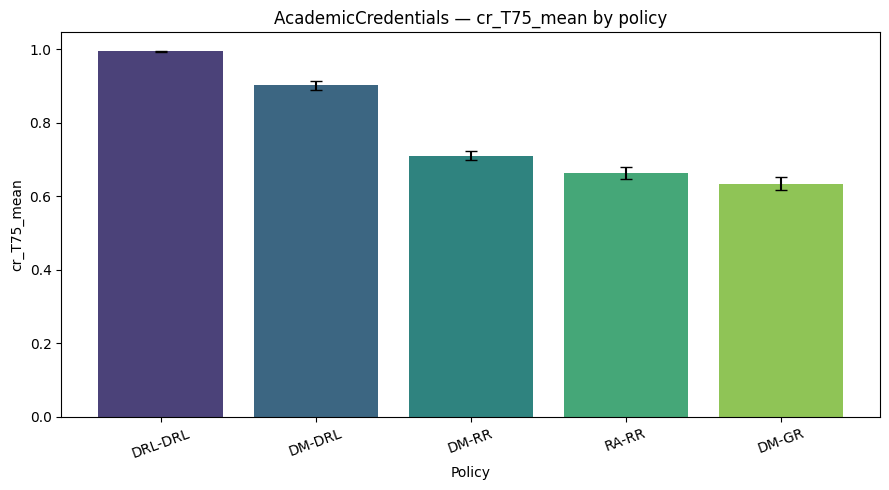

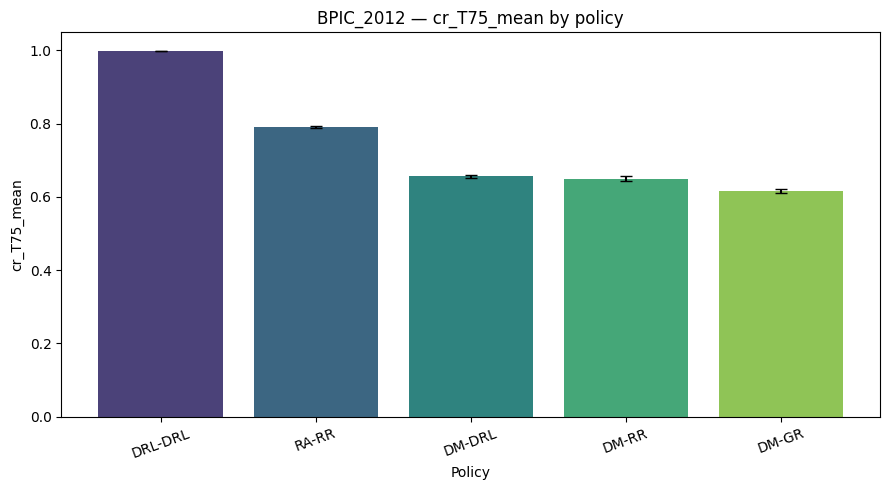

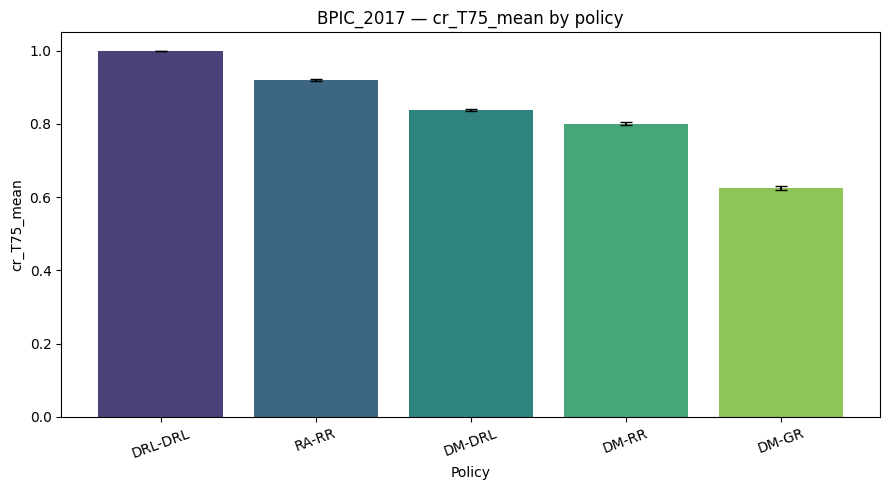

In [ ]:
logs = aggregated_df["log"].unique()
for log in logs:
    plot_policy_bar_for_log(log, "cr_T75_mean")

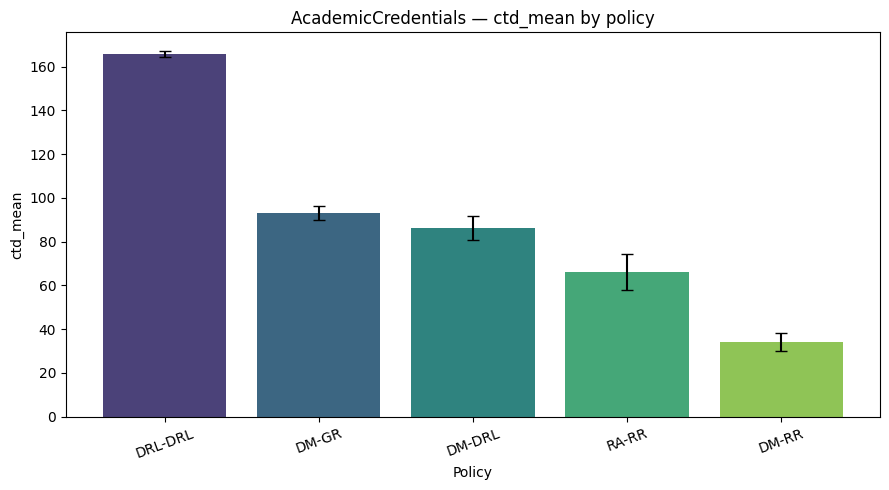

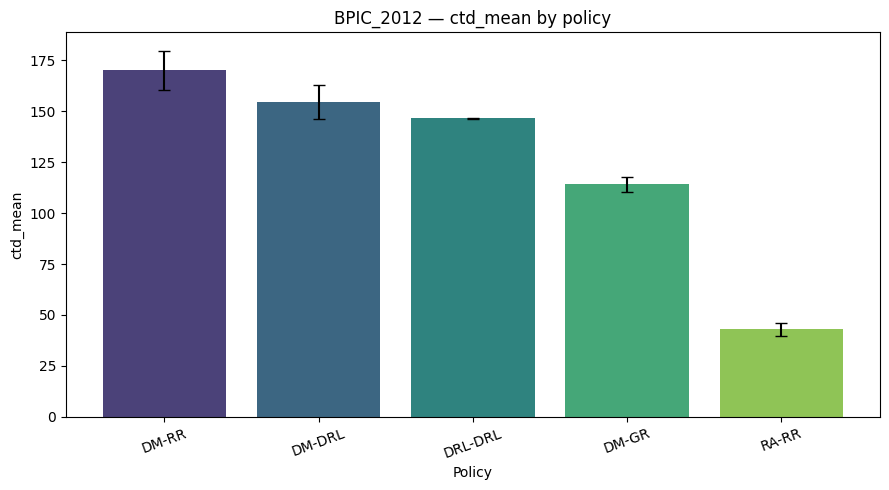

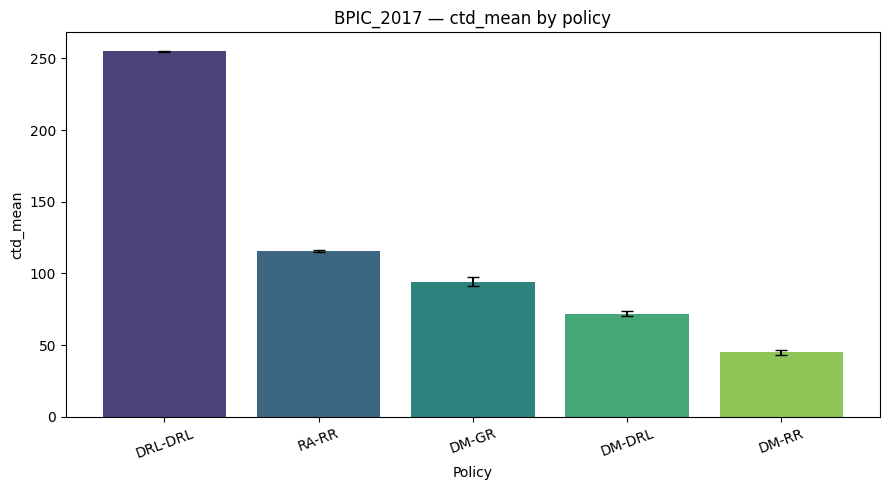

In [ ]:
logs = aggregated_df["log"].unique()
for log in logs:
    plot_policy_bar_for_log(log, "ctd_mean")

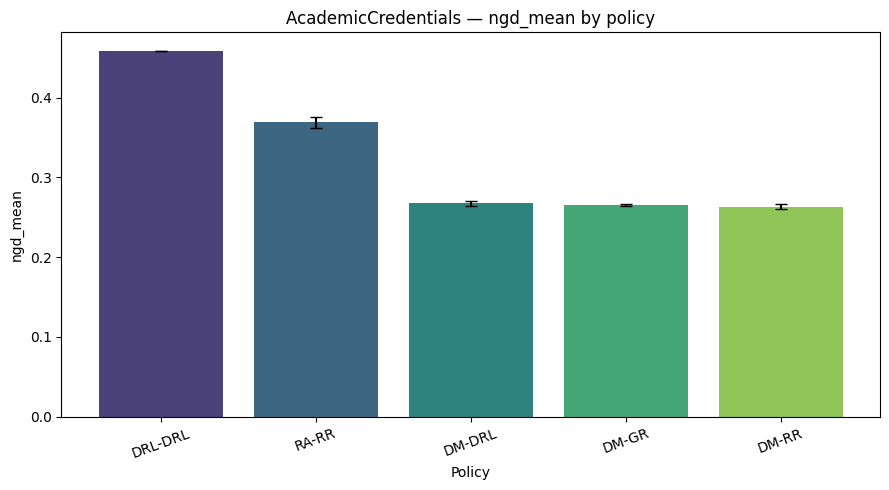

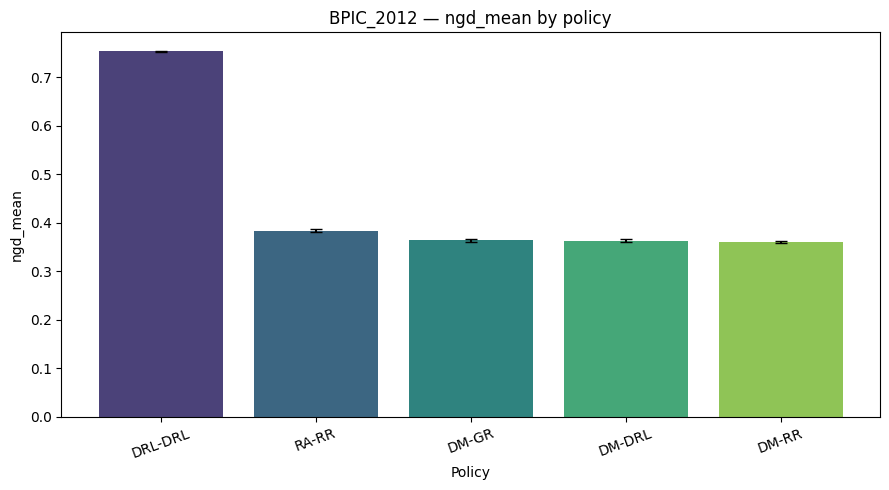

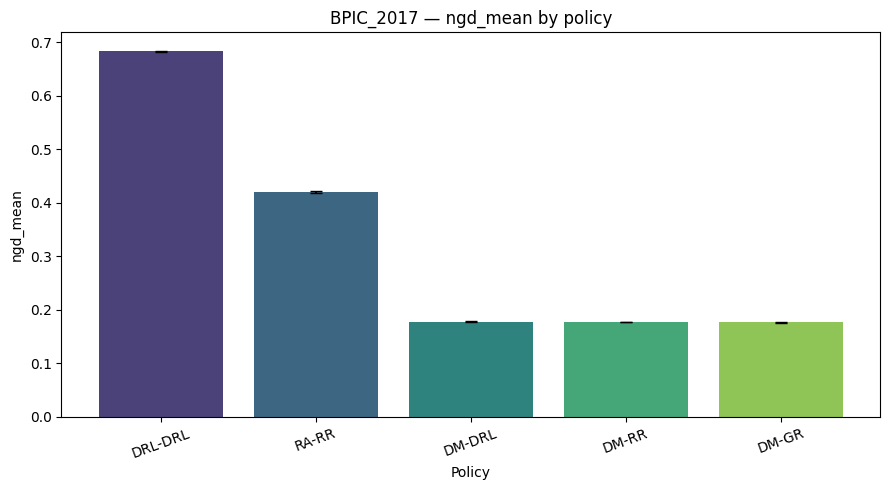

In [ ]:
logs = aggregated_df["log"].unique()
for log in logs:
    plot_policy_bar_for_log(log, "ngd_mean")

In [ ]:
def print_results(row) -> None:
    print(f"\n{'=' * 60}")
    print(f"Policy: {row['policy']} | Log: {row['log']} | Runs: {int(row['num_runs'])}")
    print(f"{'=' * 60}")

    print("\nSLA Compliance Rates (mean ± 95% CI):")
    for label in ["T95", "T90", "T75", "T50"]:
        cr = float(row[f"cr_{label}_mean"])
        ci = float(row[f"cr_{label}_ci95"])
        cir = float(row[f"cir_{label}_mean"])
        cir_ci = float(row[f"cir_{label}_ci95"])
        print(f"  {label}: CR = {cr:.2%} ± {ci:.2%}  |  CIR = {cir:+.2%} ± {cir_ci:.2%}")

    print("\nCycle Time:")
    print(f"  Mean:   {float(row['avg_ct_mean']):.1f} ± {float(row['avg_ct_ci95']):.1f}")
    print(f"  Median: {float(row['median_ct_mean']):.1f} ± {float(row['median_ct_ci95']):.1f}")
    print(f"  Std:    {float(row['std_ct_mean']):.1f}")

    if "util_cv_mean" in row and pd.notna(row["util_cv_mean"]):
        print(f"  Resource Util CV: {float(row['util_cv_mean']):.4f}")

    print("\nSimilarity Metrics (mean ± 95% CI):")
    for key in ["ngd", "aed", "ced", "red", "cwd", "car", "ctd"]:
        print(f"  {key.upper()}: {float(row[f'{key}_mean']):.4f} ± {float(row[f'{key}_ci95']):.4f}")

In [ ]:
for log in aggregated_df["log"].unique():
    log_df = aggregated_df[aggregated_df["log"] == log]
    print(f"\n\n=== Results for Log: {log} ===")
    for _, row in log_df.iterrows():
        if row["policy"] == "DM-RR":
            print_results(row)
    



=== Results for Log: AcademicCredentials ===

Policy: DM-RR | Log: AcademicCredentials | Runs: 10

SLA Compliance Rates (mean ± 95% CI):
  T95: CR = 94.45% ± 0.49%  |  CIR = -0.56% ± 0.52%
  T90: CR = 89.32% ± 0.59%  |  CIR = -0.70% ± 0.66%
  T75: CR = 71.03% ± 1.25%  |  CIR = -5.13% ± 1.67%
  T50: CR = 35.43% ± 1.80%  |  CIR = -29.15% ± 3.61%

Cycle Time:
  Mean:   772398.6 ± 15218.5
  Median: 496856.3 ± 28387.2
  Std:    856589.3
  Resource Util CV: 3.0526

Similarity Metrics (mean ± 95% CI):
  NGD: 0.2634 ± 0.0036
  AED: 76.7397 ± 13.8640
  CED: 2.0340 ± 0.1002
  RED: 22.7929 ± 1.5926
  CWD: 2.0665 ± 0.1067
  CAR: 89.8289 ± 15.7385
  CTD: 34.2452 ± 4.0630


=== Results for Log: BPIC_2012 ===

Policy: DM-RR | Log: BPIC_2012 | Runs: 10

SLA Compliance Rates (mean ± 95% CI):
  T95: CR = 84.94% ± 0.29%  |  CIR = -10.58% ± 0.31%
  T90: CR = 79.17% ± 0.46%  |  CIR = -12.04% ± 0.51%
  T75: CR = 64.99% ± 0.62%  |  CIR = -13.32% ± 0.83%
  T50: CR = 34.97% ± 0.63%  |  CIR = -30.07% ± 1.25%


In [25]:
def print_cr_cir_t75_all_logs(df=aggregated_df) -> None:
    for log in df["log"].unique():
        print(f"\n=== Log: {log} ===")
        log_df = df[df["log"] == log]
        for _, row in log_df.iterrows():
            policy = row["policy"]
            cr = float(row["cr_T75_mean"])
            cr_ci = float(row["cr_T75_ci95"])
            cir = float(row["cir_T75_mean"])
            cir_ci = float(row["cir_T75_ci95"])
            print(f"{policy}: CR_T75 = {cr:.3%} ± {cr_ci:.3%} | CIR_T75 = {cir:+.3%} ± {cir_ci:.3%}")

# Run it
print_cr_cir_t75_all_logs()


=== Log: AcademicCredentials ===
RA-RR: CR_T75 = 66.332% ± 1.688% | CIR_T75 = -11.409% ± 2.255%
DM-RR: CR_T75 = 71.030% ± 1.254% | CIR_T75 = -5.134% ± 1.675%
DM-GR: CR_T75 = 63.467% ± 1.768% | CIR_T75 = -15.235% ± 2.361%
DM-DRL: CR_T75 = 90.176% ± 1.194% | CIR_T75 = +20.436% ± 1.594%
DRL-DRL: CR_T75 = 99.422% ± 0.225% | CIR_T75 = +32.785% ± 0.300%

=== Log: BPIC_2012 ===
RA-RR: CR_T75 = 78.974% ± 0.266% | CIR_T75 = +5.321% ± 0.355%
DM-RR: CR_T75 = 64.993% ± 0.624% | CIR_T75 = -13.323% ± 0.833%
DM-GR: CR_T75 = 61.617% ± 0.605% | CIR_T75 = -17.826% ± 0.806%
DM-DRL: CR_T75 = 65.581% ± 0.374% | CIR_T75 = -12.540% ± 0.499%
DRL-DRL: CR_T75 = 99.858% ± 0.039% | CIR_T75 = +33.173% ± 0.052%

=== Log: BPIC_2017 ===
RA-RR: CR_T75 = 91.932% ± 0.321% | CIR_T75 = +22.587% ± 0.427%
DM-RR: CR_T75 = 80.074% ± 0.362% | CIR_T75 = +6.775% ± 0.482%
DM-GR: CR_T75 = 62.410% ± 0.514% | CIR_T75 = -16.779% ± 0.685%
DM-DRL: CR_T75 = 83.753% ± 0.334% | CIR_T75 = +11.681% ± 0.445%
DRL-DRL: CR_T75 = 99.984% ± 0.01